## LUT-based Quadratic Approximation of tanh(x)

This program implements a LUT-based piecewise quadratic approximation of the function `tanh(x)`.

For each segment of the input range, the approximation coefficients are calculated using:
- the interval endpoints,
- and the midpoint of the segment.

The approximated function is then compared with the exact `tanh(x)` for different LUT sizes in order to analyze:
- approximation accuracy,
- computational performance.

Num points: 2, Max error: 0.7229091167, Calculation Time: 0.0151 s
Num points: 4, Max error: 0.3920911944, Calculation Time: 0.0177 s
Num points: 8, Max error: 0.1089805413, Calculation Time: 0.0218 s
Num points: 16, Max error: 0.0168548178, Calculation Time: 0.0302 s
Num points: 32, Max error: 0.0021290302, Calculation Time: 0.0482 s
Num points: 64, Max error: 0.0002604548, Calculation Time: 0.0814 s
Num points: 128, Max error: 0.0000319968, Calculation Time: 0.1501 s
Num points: 256, Max error: 0.0000039580, Calculation Time: 0.2835 s
Num points: 512, Max error: 0.0000004917, Calculation Time: 0.5735 s
Num points: 1024, Max error: 0.0000000612, Calculation Time: 1.1488 s
Num points: 2048, Max error: 0.0000000077, Calculation Time: 2.3128 s
Num points: 4096, Max error: 0.0000000010, Calculation Time: 4.6519 s


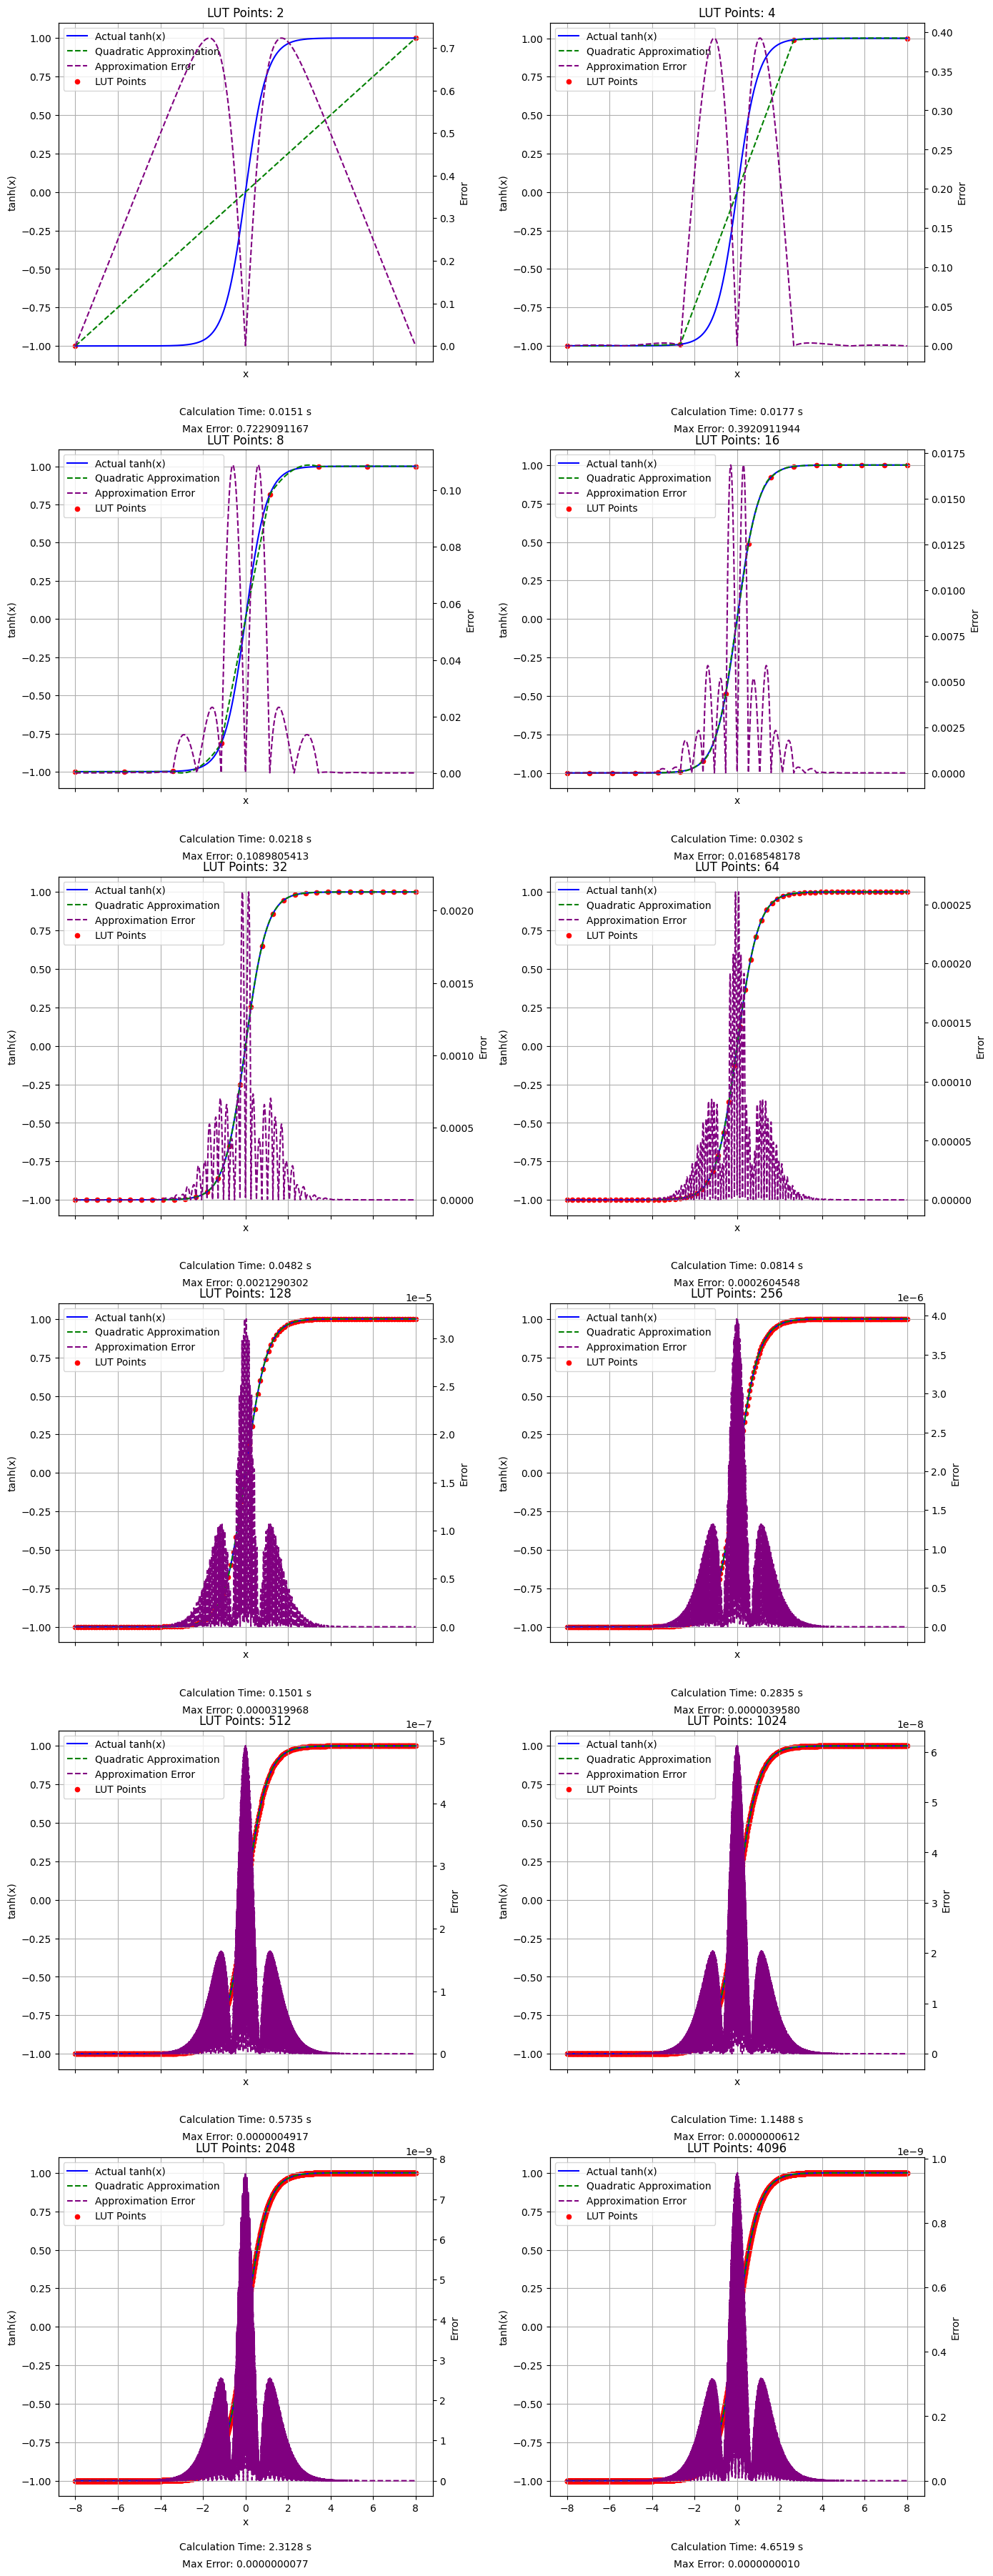

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Define the tanh(x) function
def f(x):
    return np.tanh(x)

# Function for quadratic approximation
def quadratic_approximation(x, X_k, Y_k, B_k, A_k, Delta):
    return Y_k + B_k * x + A_k * x * (Delta - x)

# Function to calculate LUT points and approximations for a given range
def calculate_lut_approximations(num_points, range_limit):
    x_k_values = np.linspace(-range_limit, range_limit, num_points)
    
    # Compute Y_k, B_k, A_k for each segment [X_k, X_{k+1}]
    Y_k_values = [f(x_k) for x_k in x_k_values]
    B_k_values = []
    A_k_values = []

    for i in range(len(x_k_values) - 1):
        X_k = x_k_values[i]
        X_k_next = x_k_values[i + 1]
        Delta = X_k_next - X_k
        Y_k = Y_k_values[i]
        Y_k_next = Y_k_values[i + 1]
        
        # Compute B_k (slope)
        B_k = (Y_k_next - Y_k) / Delta
        B_k_values.append(B_k)
        
        # Compute A_k (curvature term using midpoint)
        mid_point = X_k + Delta / 2
        f_mid = f(mid_point)
        A_k = (4 * f_mid - 2 * Y_k - 2 * Y_k_next) / (Delta ** 2)
        A_k_values.append(A_k)
    
    # Define full x range for plotting
    x_values_full = np.linspace(-range_limit, range_limit, 10000)

    # Compute actual tanh(x)
    actual_tanh_full = f(x_values_full)

    # Compute approximated tanh(x)
    approximated_tanh = []
    errors = []

    for x in x_values_full:
        # Find interval [X_k, X_{k+1}] where x belongs
        for i in range(len(x_k_values) - 1):
            if x_k_values[i] <= x <= x_k_values[i + 1]:
                X_k = x_k_values[i]
                Y_k = Y_k_values[i]
                B_k = B_k_values[i]
                A_k = A_k_values[i]
                Delta = x_k_values[i + 1] - X_k
                x_shifted = x - X_k  # x relative to X_k
                y_approx = quadratic_approximation(x_shifted, X_k, Y_k, B_k, A_k, Delta)
                
                # Store approximated value and error
                approximated_tanh.append(y_approx)
                errors.append(abs(f(x) - y_approx))
                break

    max_error = max(errors)
    
    return x_values_full, actual_tanh_full, approximated_tanh, errors, x_k_values, Y_k_values, max_error

# Set computation range
range_limit = 8  # Can be changed to any desired range

# List of LUT point counts to compare
num_points_list = [2**i for i in range(1, 13)]

# Lists to store errors and computation times
errors_full_list = []
times_full_list = []

# Create plots
fig, axs = plt.subplots(6, 2, figsize=(14, 36), sharex=True)

for idx, num_points in enumerate(num_points_list):
    # Measure computation time
    start_time = time.time()
    (x_values_full, actual_tanh_full, approximated_tanh, errors,
     lut_points_x, lut_points_y, max_error) = calculate_lut_approximations(num_points, range_limit)
    end_time = time.time()
    
    # Compute elapsed time
    elapsed_time = end_time - start_time
    
    # Store results
    errors_full_list.append(max_error)
    times_full_list.append(elapsed_time)
    
    # Print results
    print(f'Num points: {num_points}, Max error: {max_error:.10f}, Calculation Time: {elapsed_time:.4f} s')
    
    # Select subplot
    ax = axs[idx // 2, idx % 2]

    # Plot actual tanh(x) and approximation
    line1, = ax.plot(x_values_full, actual_tanh_full, label='Actual tanh(x)', color='blue')
    line2, = ax.plot(x_values_full, approximated_tanh, label='Quadratic Approximation', color='green', linestyle='--')
    points1 = ax.scatter(lut_points_x, np.tanh(lut_points_x), marker='o', s=20, color='red', label='LUT Points')

    # Plot approximation error on secondary Y axis
    ax2 = ax.twinx()
    line3, = ax2.plot(x_values_full, errors, label='Approximation Error', color='purple', linestyle='--')

    # Combine legends from both axes
    lines = [line1, line2, line3]
    points = [points1]
    
    all_artists = lines + points
    all_labels = [l.get_label() for l in all_artists if not l.get_label().startswith('_')]

    ax.legend(all_artists, all_labels, loc='upper left')
    ax2.set_ylabel('Error')

    # Titles and labels
    ax.set_title(f'LUT Points: {num_points}')
    ax.set_xlabel('x')
    ax.set_ylabel('tanh(x)')
    ax.grid(True)

    # Display computation time and max error below each plot
    ax.text(0.5, -0.15, f'Calculation Time: {elapsed_time:.4f} s', 
            ha='center', va='center', transform=ax.transAxes, fontsize=10, color='black')
    ax.text(0.5, -0.20, f'Max Error: {max_error:.10f}', 
            ha='center', va='center', transform=ax.transAxes, fontsize=10, color='black')

plt.tight_layout()
plt.show()

## Symmetric LUT Approximation of tanh(x)

This program approximates `tanh(x)` using piecewise quadratic interpolation and LUT points.

Only the positive range is computed, while the negative range is reconstructed using the symmetry:
`tanh(-x) = -tanh(x)`.

The approximation is evaluated for different LUT sizes in terms of accuracy and computation time.

Num points: 2, Max error: 0.4290277257, Calculation Time: 0.0085 s
Num points: 4, Max error: 0.0605748224, Calculation Time: 0.0092 s
Num points: 8, Max error: 0.0081013568, Calculation Time: 0.0113 s
Num points: 16, Max error: 0.0019189680, Calculation Time: 0.0159 s
Num points: 32, Max error: 0.0002605954, Calculation Time: 0.0249 s
Num points: 64, Max error: 0.0000323886, Calculation Time: 0.0459 s
Num points: 128, Max error: 0.0000039906, Calculation Time: 0.0784 s
Num points: 256, Max error: 0.0000004943, Calculation Time: 0.1495 s
Num points: 512, Max error: 0.0000000615, Calculation Time: 0.2945 s
Num points: 1024, Max error: 0.0000000077, Calculation Time: 0.6011 s
Num points: 2048, Max error: 0.0000000010, Calculation Time: 1.2078 s
Num points: 4096, Max error: 0.0000000001, Calculation Time: 2.3942 s


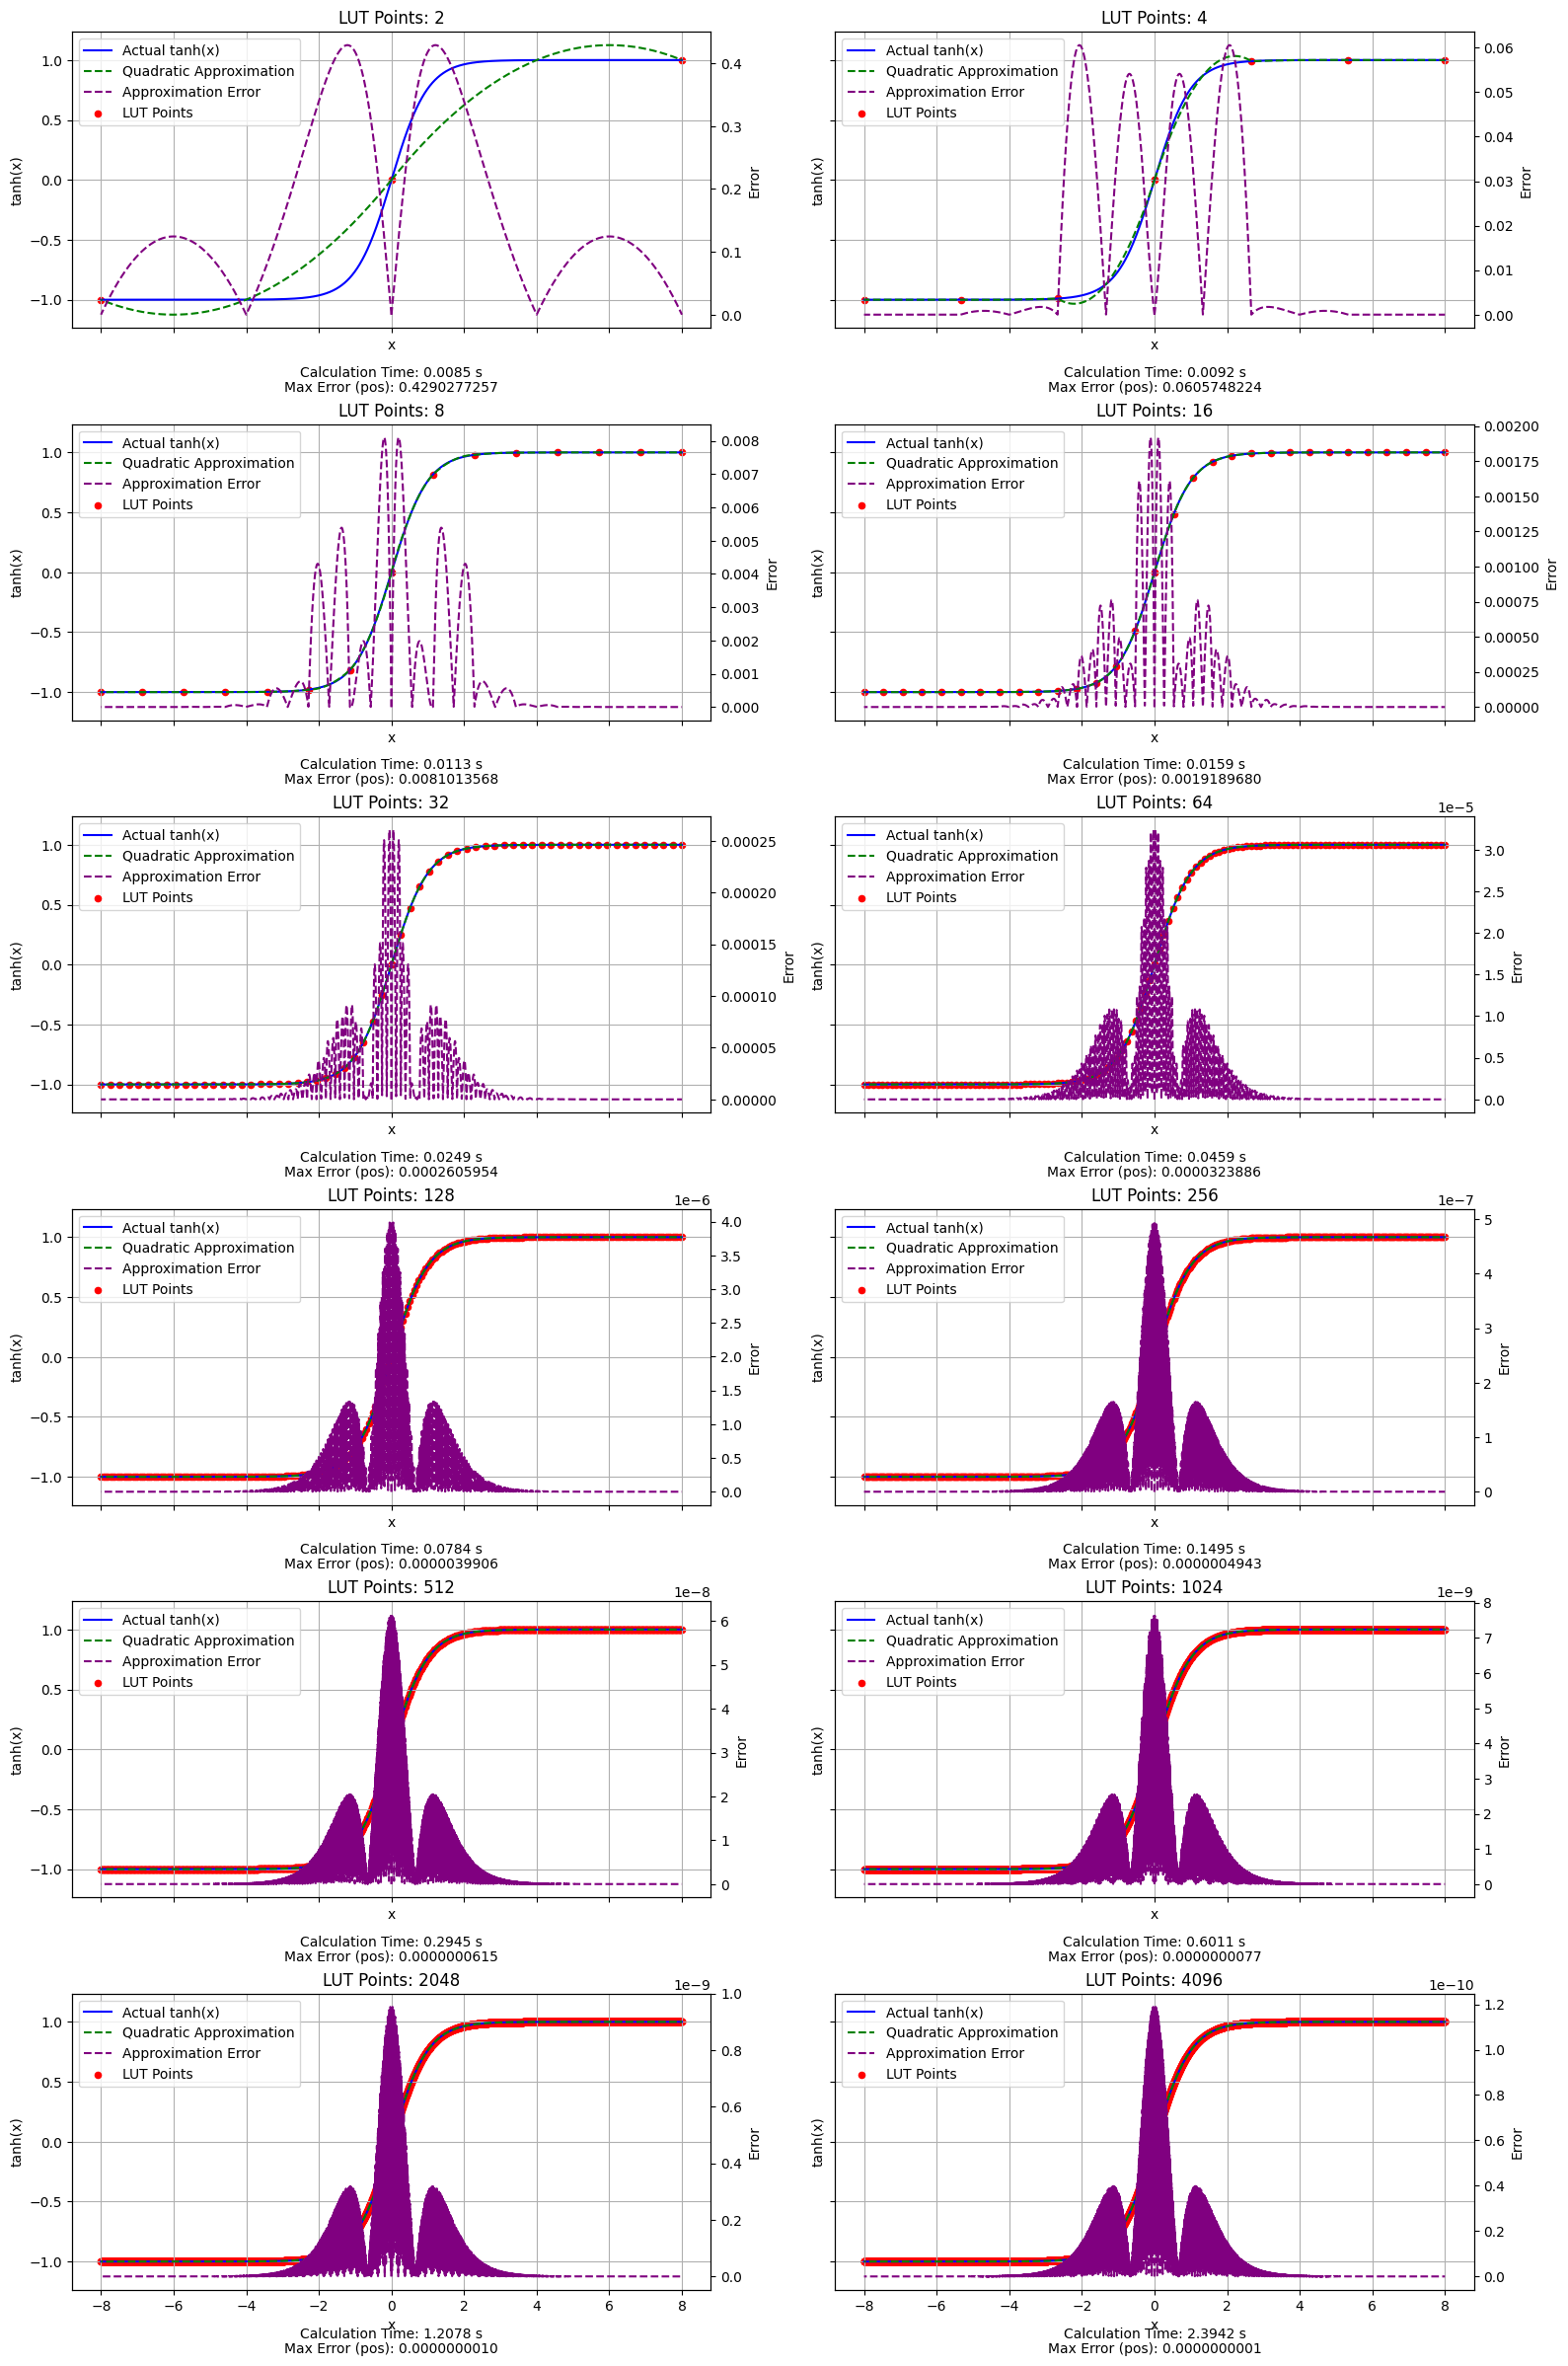

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Define the tanh(x) function
def f(x):
    return np.tanh(x)

# Function for quadratic approximation
def quadratic_approximation(x, X_k, Y_k, B_k, A_k, Delta):
    return Y_k + B_k * x + A_k * x * (Delta - x)

# Function to compute LUT points and approximations for a given range
def calculate_lut_approximations(num_points, range_limit):
    x_k_values = np.linspace(0, range_limit, num_points)
    
    # Compute Y_k, B_k, A_k for each segment [X_k, X_{k+1}]
    Y_k_values = [f(x_k) for x_k in x_k_values]
    B_k_values = []
    A_k_values = []

    for i in range(len(x_k_values) - 1):
        X_k = x_k_values[i]
        X_k_next = x_k_values[i + 1]
        Delta = X_k_next - X_k
        Y_k = Y_k_values[i]
        Y_k_next = Y_k_values[i + 1]
        
        # Compute B_k (slope)
        B_k = (Y_k_next - Y_k) / Delta
        B_k_values.append(B_k)
        
        # Compute A_k using midpoint
        mid_point = X_k + Delta / 2
        f_mid = f(mid_point)
        A_k = (4 * f_mid - 2 * Y_k - 2 * Y_k_next) / (Delta ** 2)
        A_k_values.append(A_k)
    
    # Define x ranges for plotting
    x_values_pos = np.linspace(0, range_limit, 5000)
    x_values_neg = -np.linspace(0, range_limit, 5000)

    # Compute actual tanh(x) values
    actual_tanh_pos = f(x_values_pos)
    actual_tanh_neg = -f(x_values_pos)  # Reflection across Y-axis

    # Compute approximated tanh(x) values
    approximated_tanh_pos = []
    approximated_tanh_neg = []
    errors_pos = []
    errors_neg = []

    for x in x_values_pos:
        # Find interval [X_k, X_{k+1}] where x belongs
        for i in range(len(x_k_values) - 1):
            if x_k_values[i] <= x <= x_k_values[i + 1]:
                X_k = x_k_values[i]
                Y_k = Y_k_values[i]
                B_k = B_k_values[i]
                A_k = A_k_values[i]
                Delta = x_k_values[i + 1] - X_k
                x_shifted = x - X_k  # x relative to X_k
                y_approx = quadratic_approximation(x_shifted, X_k, Y_k, B_k, A_k, Delta)
                
                # Store approximated value and error
                approximated_tanh_pos.append(y_approx)
                approximated_tanh_neg.append(-y_approx)  # Reflection of approximated value
                errors_pos.append(abs(actual_tanh_pos[len(approximated_tanh_pos) - 1] - y_approx))
                errors_neg.append(abs(actual_tanh_neg[len(approximated_tanh_neg) - 1] + y_approx))
                break

    max_error_pos = max(errors_pos)
    max_error_neg = max(errors_neg)
    
    return (x_values_pos, actual_tanh_pos, approximated_tanh_pos, errors_pos,
            x_values_neg, actual_tanh_neg, approximated_tanh_neg, errors_neg,
            x_k_values, Y_k_values, max_error_pos, max_error_neg)

# Set computation range
range_limit = 8  # Can be changed to any desired range

# Numbers of LUT points to compare
num_points_list = [2**i for i in range(1, 13)]

# Lists to store errors and execution times
errors_symmetric = []
times_symmetric = []

# Create plots
fig, axs = plt.subplots(6, 2, figsize=(16, 24), sharex=True, sharey=True)  # Changed layout to 6x2 and figure size to 16x24

for idx, num_points in enumerate(num_points_list):
    # Measure computation time
    start_time = time.time()
    (x_values_pos, actual_tanh_pos, approximated_tanh_pos, errors_pos,
     x_values_neg, actual_tanh_neg, approximated_tanh_neg, errors_neg,
     lut_points_x, lut_points_y, max_error_pos, max_error_neg) = calculate_lut_approximations(num_points, range_limit)
    end_time = time.time()
    
    # Compute elapsed time
    elapsed_time = end_time - start_time
    
    # Store results
    errors_symmetric.append(max_error_pos)
    times_symmetric.append(elapsed_time)
    
    # Print maximum errors
    print(f'Num points: {num_points}, Max error: {max_error_pos:.10f}, Calculation Time: {elapsed_time:.4f} s')
    
    # Select subplot
    ax = axs[idx // 2, idx % 2]

    # Plot actual tanh(x) and approximation
    x_values_full = np.linspace(-range_limit, range_limit, 10000)
    actual_tanh_full = f(x_values_full)

    line1, = ax.plot(x_values_full, actual_tanh_full, label='Actual tanh(x)', color='blue')
    line2, = ax.plot(x_values_pos, approximated_tanh_pos, label='Quadratic Approximation', color='green', linestyle='--')
    line3, = ax.plot(x_values_neg, approximated_tanh_neg, color='green', linestyle='--')
    points1 = ax.scatter(lut_points_x, np.tanh(lut_points_x), marker='o', s=20, color='red', label='LUT Points')
    points2 = ax.scatter(-lut_points_x, -np.tanh(lut_points_x), marker='o', s=20, color='red')

    # Plot approximation error on secondary Y-axis
    ax2 = ax.twinx()
    line4, = ax2.plot(x_values_pos, errors_pos, label='Approximation Error', color='purple', linestyle='--')
    line5, = ax2.plot(x_values_neg, errors_neg, color='purple', linestyle='--')

    # Combine legends from both axes
    lines = [line1, line2, line4]
    points = [points1]
    
    all_artists = lines + points
    all_labels = [l.get_label() for l in all_artists if not l.get_label().startswith('_')]

    ax.legend(all_artists, all_labels, loc='upper left')
    ax2.set_ylabel('Error')

    # Title and labels
    ax.set_title(f'LUT Points: {num_points}')
    ax.set_xlabel('x')
    ax.set_ylabel('tanh(x)')
    ax.grid(True)

    # Display computation time and max error below each plot
    ax.text(0.5, -0.15, f'Calculation Time: {elapsed_time:.4f} s', 
            ha='center', va='center', transform=ax.transAxes, fontsize=10, color='black')
    ax.text(0.5, -0.20, f'Max Error (pos): {max_error_pos:.10f}', 
            ha='center', va='center', transform=ax.transAxes, fontsize=10, color='black')

plt.tight_layout()
plt.show()

## LUT Approximation Comparison

This section compares the full and symmetric implementations of the tanh(x) approximation.

It evaluates accuracy and computation time for different LUT sizes and visualizes:
- maximum error,
- execution time.

Logarithmic scales are used to highlight performance trends.

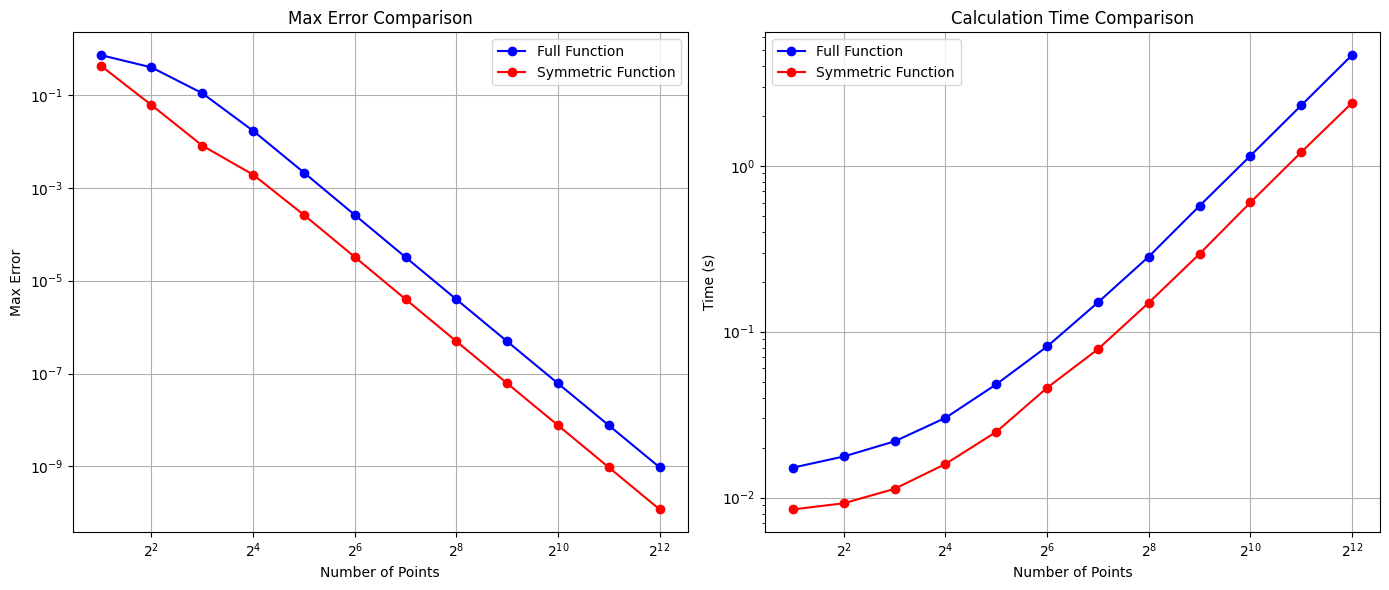

In [6]:
import numpy as np
import matplotlib.pyplot as plt

num_points_list = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]

# Compute differences in accuracy and computation time
error_diff = np.array(errors_symmetric) - np.array(errors_full_list)
time_diff = np.array(times_symmetric) - np.array(times_full_list)
speedup = np.array(times_full_list) / np.array(times_symmetric)

# Comparison plots
fig, axs = plt.subplots(1, 2, figsize=(14, 6))  # Reduced figure height

# Maximum error
axs[0].plot(num_points_list, errors_full_list, 'o-', label='Full Function', color='blue')
axs[0].plot(num_points_list, errors_symmetric, 'o-', label='Symmetric Function', color='red')
axs[0].set_xscale('log', base=2)
axs[0].set_yscale('log')
axs[0].set_xlabel('Number of Points')
axs[0].set_ylabel('Max Error')
axs[0].set_title('Max Error Comparison')
axs[0].legend()
axs[0].grid(True)

# Computation time
axs[1].plot(num_points_list, times_full_list, 'o-', label='Full Function', color='blue')
axs[1].plot(num_points_list, times_symmetric, 'o-', label='Symmetric Function', color='red')
axs[1].set_xscale('log', base=2)
axs[1].set_yscale('log')
axs[1].set_xlabel('Number of Points')
axs[1].set_ylabel('Time (s)')
axs[1].set_title('Calculation Time Comparison')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

## Comparison of Symmetric and Non-Symmetric Function Results

The symmetric function provides clear advantages compared to the non-symmetric approach:

- **Accuracy:** The symmetric function achieves significantly lower maximum errors. For a larger number of points, the maximum error is about an order of magnitude smaller than in the non-symmetric case.
  
- **Time Efficiency:** The computation time for the symmetric function grows more slowly with the number of points. For the largest number of points, the computation time is significantly shorter than for the non-symmetric function, making it more efficient.

In the case of the non-symmetric function, the increasing computation time becomes a significant limitation, especially for larger datasets. Therefore, in the following analysis, we will focus on the impact of increasing the range for the symmetric function to fully exploit its advantages in terms of accuracy and computational efficiency.

## Optimization of Computation Using the Symmetric Function

Using the symmetric function allows for computing a larger number of points in a shorter time. By exploiting symmetry, part of the points is obtained by mirroring the function, which effectively doubles the number of points outside zero. In practice, this means that the number of computed points in the symmetric function is nearly twice as large as in the non-symmetric case. The more points are computed, the greater the difference between these two methods, highlighting the advantage of the symmetric function in computations.

In [7]:
import numpy as np
import time

# Define the tanh(x) function
def f(x):
    return np.tanh(x)

# Function for quadratic approximation
def quadratic_approximation(x, X_k, Y_k, B_k, A_k, Delta):
    return Y_k + B_k * x + A_k * x * (Delta - x)

# Function to compute LUT points and approximations for a given range
def calculate_lut_approximations(num_points, range_limit):
    x_k_values = np.linspace(0, range_limit, num_points)
    
    # Compute Y_k, B_k, A_k for each segment [X_k, X_{k+1}]
    Y_k_values = [f(x_k) for x_k in x_k_values]
    B_k_values = []
    A_k_values = []

    for i in range(len(x_k_values) - 1):
        X_k = x_k_values[i]
        X_k_next = x_k_values[i + 1]
        Delta = X_k_next - X_k
        Y_k = Y_k_values[i]
        Y_k_next = Y_k_values[i + 1]
        
        # Compute B_k (slope)
        B_k = (Y_k_next - Y_k) / Delta
        B_k_values.append(B_k)
        
        # Compute A_k using midpoint
        mid_point = X_k + Delta / 2
        f_mid = f(mid_point)
        A_k = (4 * f_mid - 2 * Y_k - 2 * Y_k_next) / (Delta ** 2)
        A_k_values.append(A_k)
    
    # Define x ranges for computation
    x_values_pos = np.linspace(0, range_limit, 5000)
    x_values_neg = -np.linspace(0, range_limit, 5000)

    # Compute actual tanh(x) values
    actual_tanh_pos = f(x_values_pos)
    actual_tanh_neg = -f(x_values_pos)  # Reflection across Y-axis

    # Compute approximated tanh(x) values
    approximated_tanh_pos = []
    approximated_tanh_neg = []
    errors_pos = []
    errors_neg = []

    for x in x_values_pos:
        # Find interval [X_k, X_{k+1}] where x belongs
        for i in range(len(x_k_values) - 1):
            if x_k_values[i] <= x <= x_k_values[i + 1]:
                X_k = x_k_values[i]
                Y_k = Y_k_values[i]
                B_k = B_k_values[i]
                A_k = A_k_values[i]
                Delta = x_k_values[i + 1] - X_k
                x_shifted = x - X_k  # x relative to X_k
                y_approx = quadratic_approximation(x_shifted, X_k, Y_k, B_k, A_k, Delta)
                
                # Store approximated value and error
                approximated_tanh_pos.append(y_approx)
                approximated_tanh_neg.append(-y_approx)  # Reflection of approximated value
                errors_pos.append(abs(actual_tanh_pos[len(approximated_tanh_pos) - 1] - y_approx))
                errors_neg.append(abs(actual_tanh_neg[len(approximated_tanh_neg) - 1] + y_approx))
                break

    max_error_pos = max(errors_pos)
    max_error_neg = max(errors_neg)
    
    return max_error_pos, max_error_neg

# Numbers of LUT points to compare
num_points_list = [2**i for i in range(1, 13)]

# Ranges for computation
range_limits = [1, 2, 4, 8, 16]

# Initialize lists to store errors and computation times
errors_1, times_1 = [], []
errors_2, times_2 = [], []
errors_4, times_4 = [], []
errors_8, times_8 = [], []
errors_16, times_16 = [], []

# Compute results for different ranges
for range_limit in range_limits:
    for num_points in num_points_list:
        start_time = time.time()
        max_error = calculate_lut_approximations(num_points, range_limit)
        end_time = time.time()
        
        elapsed_time = end_time - start_time
        
        # Assign results to corresponding lists
        if range_limit == 1:
            errors_1.append(max_error)
            times_1.append(elapsed_time)
        elif range_limit == 2:
            errors_2.append(max_error)
            times_2.append(elapsed_time)
        elif range_limit == 4:
            errors_4.append(max_error)
            times_4.append(elapsed_time)
        elif range_limit == 8:
            errors_8.append(max_error)
            times_8.append(elapsed_time)
        elif range_limit == 16:
            errors_16.append(max_error)
            times_16.append(elapsed_time)

# Display results
"""
print("Errors and Times for range_limit = 1")
print("Max Errors (Positive):", errors_1)
print("Times:", times_1)

print("\nErrors and Times for range_limit = 2")
print("Max Errors (Positive):", errors_2)
print("Times:", times_2)

print("\nErrors and Times for range_limit = 4")
print("Max Errors (Positive):", errors_4)
print("Times:", times_4)

print("\nErrors and Times for range_limit = 8")
print("Max Errors (Positive):", errors_8)
print("Times:", times_8)

print("\nErrors and Times for range_limit = 16")
print("Max Errors (Positive):", errors_16)
print("Times:", times_16)
"""
print("Computed")

Computed


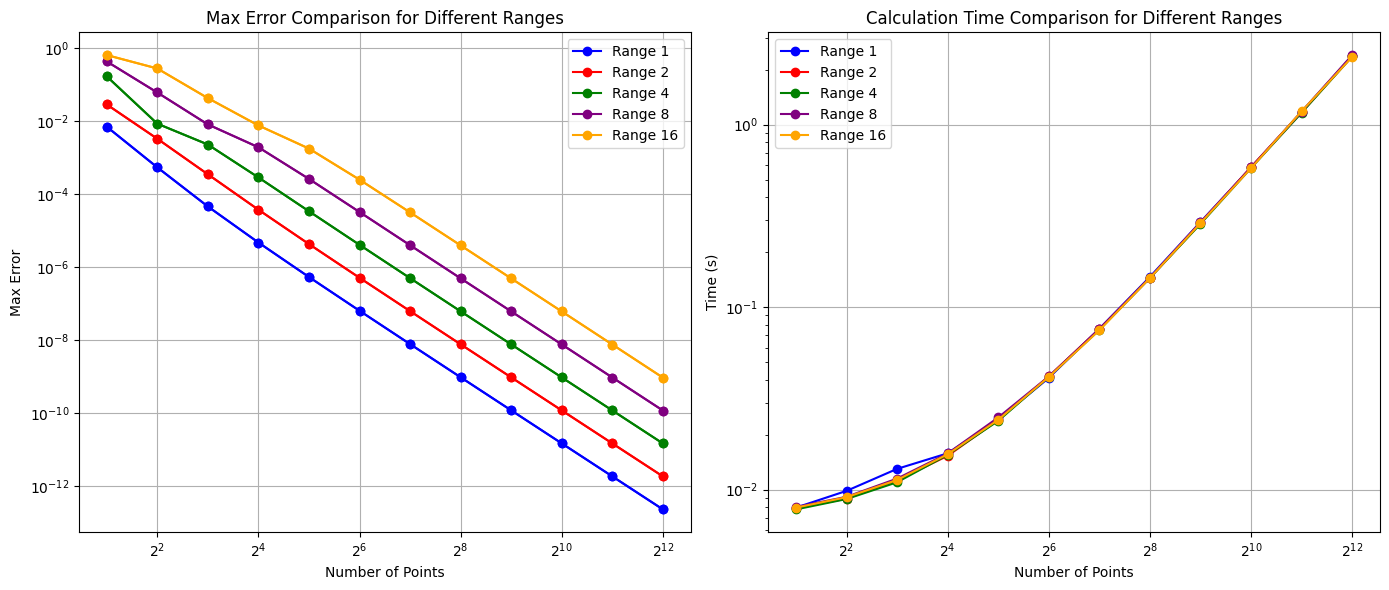

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Number of points to use in the plots
num_points_list = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Max Error Comparison
axs[0].plot(num_points_list, errors_1, 'o-', color='blue')
axs[0].plot(num_points_list, errors_2, 'o-', color='red')
axs[0].plot(num_points_list, errors_4, 'o-', color='green')
axs[0].plot(num_points_list, errors_8, 'o-', color='purple')
axs[0].plot(num_points_list, errors_16, 'o-', color='orange')

# Create custom legend handles
legend_handles = [
    Line2D([0], [0], color='blue', marker='o', linestyle='-', label='Range 1'),
    Line2D([0], [0], color='red', marker='o', linestyle='-', label='Range 2'),
    Line2D([0], [0], color='green', marker='o', linestyle='-', label='Range 4'),
    Line2D([0], [0], color='purple', marker='o', linestyle='-', label='Range 8'),
    Line2D([0], [0], color='orange', marker='o', linestyle='-', label='Range 16'),
]

axs[0].set_xscale('log', base=2)
axs[0].set_yscale('log')
axs[0].set_xlabel('Number of Points')
axs[0].set_ylabel('Max Error')
axs[0].set_title('Max Error Comparison for Different Ranges')
axs[0].legend(handles=legend_handles)
axs[0].grid(True)

# Calculation Time Comparison
axs[1].plot(num_points_list, times_1, 'o-', color='blue')
axs[1].plot(num_points_list, times_2, 'o-', color='red')
axs[1].plot(num_points_list, times_4, 'o-', color='green')
axs[1].plot(num_points_list, times_8, 'o-', color='purple')
axs[1].plot(num_points_list, times_16, 'o-', color='orange')

# Create custom legend handles
legend_handles = [
    Line2D([0], [0], color='blue', marker='o', linestyle='-', label='Range 1'),
    Line2D([0], [0], color='red', marker='o', linestyle='-', label='Range 2'),
    Line2D([0], [0], color='green', marker='o', linestyle='-', label='Range 4'),
    Line2D([0], [0], color='purple', marker='o', linestyle='-', label='Range 8'),
    Line2D([0], [0], color='orange', marker='o', linestyle='-', label='Range 16'),
]

axs[1].set_xscale('log', base=2)
axs[1].set_yscale('log')
axs[1].set_xlabel('Number of Points')
axs[1].set_ylabel('Time (s)')
axs[1].set_title('Calculation Time Comparison for Different Ranges')
axs[1].legend(handles=legend_handles)
axs[1].grid(True)

plt.tight_layout()
plt.show()


## Analysis of Results for the Symmetric Function

Increasing the range of the symmetric function affects both the approximation error and the computation time. Larger ranges lead to higher maximum errors and longer computation times, which may be related to increased computational complexity and potential impacts on numerical precision. Symmetric functions within smaller ranges are more efficient in terms of both accuracy and computation time.